In [93]:
import pandas as pd

pm25 = pd.read_excel("PM2.5_Exposure.xls", sheet_name="Data", skiprows=2)
life = pd.read_excel("Life_expectancies.xls", sheet_name="Data", skiprows=2)
gdp = pd.read_excel("GDP_per_capita.xls", sheet_name="Data", skiprows=2)
health = pd.read_excel("health_expenditure.xls", sheet_name="Data", skiprows=2)

In [94]:
def clean_worldbank_df(df, value_name):
    # fix column headers
    df.columns = df.iloc[0]
    df = df.drop(0).reset_index(drop=True)

    # rename country column
    df = df.rename(columns={"Country Name": "Country"})

    # drop redundant columns & convert to strings
    df = df.drop(columns=["Country Code", "Indicator Name", "Indicator Code"], errors="ignore")
    df.columns = df.columns.astype(str)

    # melt year columns into one 'Year' column
    df = df.melt(
        id_vars=["Country"],
        var_name="Year",
        value_name=value_name
    )

    # keep actual year
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])

    # year as int_type
    df["Year"] = df["Year"].astype(int)

    return df

In [95]:
# apply initial cleaning function to all datasets
pm25 = clean_worldbank_df(pm25, "PM25")
life = clean_worldbank_df(life, "LifeExp")
gdp = clean_worldbank_df(gdp, "GDP")
health = clean_worldbank_df(health, "HealthExp")

In [96]:
gdp.head()

,Country,Year,GDP
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,NaN
2,Afghanistan,1960,NaN
3,Africa Western and Central,1960,NaN
4,Angola,1960,NaN


In [97]:
# merging datasets
df = pm25.merge(life, on=["Country", "Year"], how="inner")
df = df.merge(gdp, on=["Country", "Year"], how="inner")
df = df.merge(health, on=["Country", "Year"], how="inner")

In [98]:
df.head()

,Country,Year,PM25,LifeExp,GDP,HealthExp
0,Aruba,1960,NaN,64.049000,NaN,NaN
1,Africa Eastern and Southern,1960,NaN,44.169658,NaN,NaN
2,Afghanistan,1960,NaN,32.799000,NaN,NaN
3,Africa Western and Central,1960,NaN,37.779636,NaN,NaN
4,Angola,1960,NaN,37.933000,NaN,NaN


In [99]:
# merged data description
print(df.shape)
print(df.isna().sum())
print(df.describe())

(17556, 6)
Country          0
Year             0
PM25          9868
LifeExp        630
GDP           9045
HealthExp    11846
dtype: int64
               Year         PM25       LifeExp            GDP     HealthExp
count  17556.000000  7688.000000  16926.000000    8511.000000   5710.000000
mean    1992.500000    28.390587     64.735082   16308.860758   1251.598438
std       19.050914    16.436362     11.080176   19995.773964   1733.644790
min     1960.000000     4.895181     10.989000     254.388475      6.106393
25%     1976.000000    16.755624     57.661500    3235.851569    174.489841
50%     1992.500000    23.958606     67.091500    8458.841233    554.732148
75%     2009.000000    39.223020     72.914677   21620.474104   1509.649343
max     2025.000000   107.144665     86.372000  180939.439450  13473.193217


In [100]:
# view yearly variable nulls
missing_pct = df.groupby("Year").apply(lambda x: x.isna().mean() * 100)
pd.set_option('display.max_rows', None)
print(missing_pct)

      Country  Year        PM25    LifeExp         GDP   HealthExp
Year                                                              
1960      0.0   0.0  100.000000    1.12782  100.000000  100.000000
1961      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1962      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1963      0.0   0.0  100.000000    1.12782  100.000000  100.000000
1964      0.0   0.0  100.000000    1.12782  100.000000  100.000000
1965      0.0   0.0  100.000000    1.12782  100.000000  100.000000
1966      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1967      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1968      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1969      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1970      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1971      0.0   0.0  100.000000    0.75188  100.000000  100.000000
1972      0.0   0.0  100.000000    0.75188  100.000000  100.00

/tmp/ipykernel_21501/1638141631.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_pct = df.groupby("Year").apply(lambda x: x.isna().mean() * 100)


In [101]:
pd.reset_option('display.max_rows')

In [102]:
# restrict year from 2000 - 2020
df = df[(df["Year"] >= 2000) & (df["Year"] <= 2020)]
df = df.dropna()
df

,Country,Year,PM25,LifeExp,GDP,HealthExp
10641,Africa Eastern and Southern,2000,26.783513,52.557342,2167.022577,114.620868
10643,Africa Western and Central,2000,62.567611,50.297983,2457.445111,69.556528
10644,Angola,2000,23.509342,46.501000,3689.537808,63.408126
10645,Albania,2000,22.265189,74.826000,3977.771869,223.932378
10646,Andorra,2000,16.221599,81.863000,33458.118163,1919.341249
...,...,...,...,...,...,...
16218,Vanuatu,2020,14.082412,70.385000,3117.644253,128.486941
16219,World,2020,31.323839,72.181979,17911.490598,1568.997831
16220,Samoa,2020,12.551895,70.727000,6450.752012,392.897985
16223,South Africa,2020,23.753069,65.150000,12671.086244,1143.152470


In [103]:
# cleaned data description
print(df.shape)
print(df.isna().sum())
print(df.describe().round(2))

(4866, 6)
Country      0
Year         0
PM25         0
LifeExp      0
GDP          0
HealthExp    0
dtype: int64
          Year     PM25  LifeExp        GDP  HealthExp
count  4866.00  4866.00  4866.00    4866.00    4866.00
mean   2010.04    28.53    69.58   16187.23    1096.09
std       6.05    16.69     8.55   18696.69    1473.51
min    2000.00     4.90    14.66     403.98       6.11
25%    2005.00    16.43    64.03    3659.04     163.75
50%    2010.00    23.60    71.00    9490.63     507.91
75%    2015.00    39.44    75.81   21252.53    1298.76
max    2020.00   107.14    85.26  180939.44   11648.50


PART 1 EXPLANATION:

PM2.5 exposure is measured as the annual mean concentration of fine particulate matter. Life expectancy is measured in years at birth. GDP per capita captures economic development, while health expenditure represents public and private health spending per capita.

In [104]:
import numpy as np

df["log_PM25"] = np.log(df["PM25"])
df["log_GDP"] = np.log(df["GDP"])
df["log_HealthExp"] = np.log(df["HealthExp"])
df

,Country,Year,PM25,LifeExp,GDP,HealthExp,log_PM25,log_GDP,log_HealthExp
10641,Africa Eastern and Southern,2000,26.783513,52.557342,2167.022577,114.620868,3.287787,7.681109,4.741630
10643,Africa Western and Central,2000,62.567611,50.297983,2457.445111,69.556528,4.136248,7.806878,4.242140
10644,Angola,2000,23.509342,46.501000,3689.537808,63.408126,3.157398,8.213256,4.149592
10645,Albania,2000,22.265189,74.826000,3977.771869,223.932378,3.103024,8.288477,5.411344
10646,Andorra,2000,16.221599,81.863000,33458.118163,1919.341249,2.786344,10.418050,7.559737
...,...,...,...,...,...,...,...,...,...
16218,Vanuatu,2020,14.082412,70.385000,3117.644253,128.486941,2.644927,8.044833,4.855827
16219,World,2020,31.323839,72.181979,17911.490598,1568.997831,3.444379,9.793198,7.358192
16220,Samoa,2020,12.551895,70.727000,6450.752012,392.897985,2.529872,8.771952,5.973550
16223,South Africa,2020,23.753069,65.150000,12671.086244,1143.152470,3.167712,9.447078,7.041545


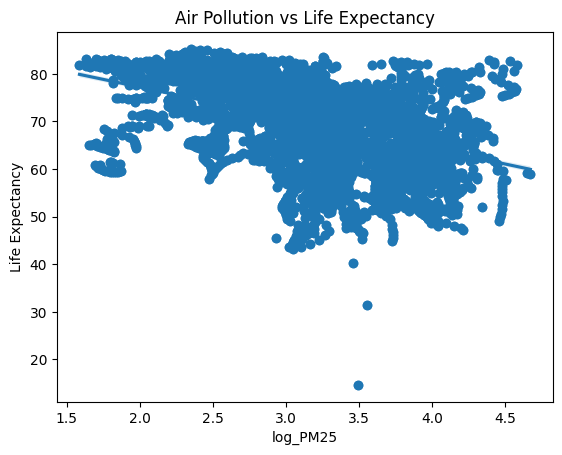

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df["log_PM25"], df["LifeExp"])
plt.xlabel("PM2.5")
sns.regplot(x="log_PM25", y="LifeExp", data=df)
plt.ylabel("Life Expectancy")
plt.title("Air Pollution vs Life Expectancy")
plt.show()


OLS Regression EQN:

LifeExpit​=β0​+β1​log(PM2.5it​)+β2​log(GDPit​)+β3​log(HealthExpit​)+ϵit​

In [106]:
import statsmodels.api as sm

X = df[["log_PM25", "log_GDP", "log_HealthExp"]]
X = sm.add_constant(X)

y = df["LifeExp"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     4204.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:34:49   Log-Likelihood:                -14234.
No. Observations:                4866   AIC:                         2.848e+04
Df Residuals:                    4862   BIC:                         2.850e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            26.4936      0.895     29.617

The regression results show that air pollution has a statistically significant negative impact on life expectancy. A 1% increase in PM2.5 exposure is associated with a decline in life expectancy, holding other factors constant. In contrast, GDP per capita and health expenditure are positively associated with life expectancy.

Key findings from your output:

R² = 0.72 → strong model

log_PM25 = -0.2257 (NOT significant, p = 0.102)

log_GDP = +2.66 (significant)

log_HealthExp = +3.17 (significant)

Interpretation:

Pollution effect is negative (expected) but not statistically significant

Economic factors are very strong drivers of life expectancy

The regression results indicate that GDP per capita and health expenditure have a positive and statistically significant impact on life expectancy. Specifically, higher levels of income and healthcare spending are associated with improved health outcomes across countries.

The coefficient on PM2.5 exposure is negative, suggesting that higher pollution is associated with lower life expectancy. However, the effect is not statistically significant at conventional levels. This may indicate that the impact of pollution is partially captured by economic and healthcare variables, or that cross-country variation masks localized effects.

In [107]:
# Fix: Use robust standard errors
model = sm.OLS(y, X).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     5037.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:40:23   Log-Likelihood:                -14234.
No. Observations:                4866   AIC:                         2.848e+04
Df Residuals:                    4862   BIC:                         2.850e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            26.4936      0.990     26.762

In [108]:
# Model 2: Without logs
X2 = df[["PM25", "GDP", "HealthExp"]]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit(cov_type='HC1')
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     1361.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:40:42   Log-Likelihood:                -15573.
No. Observations:                4866   AIC:                         3.115e+04
Df Residuals:                    4862   BIC:                         3.118e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.1765      0.224    303.708      0.0

In [110]:
# Model 3: Year Fixed Effects
import statsmodels.formula.api as smf

model3 = smf.ols(
    "LifeExp ~ log_PM25 + log_GDP + log_HealthExp + C(Year)",
    data=df
).fit(cov_type='HC1')

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeExp   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     682.2
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:42:27   Log-Likelihood:                -14226.
No. Observations:                4866   AIC:                         2.850e+04
Df Residuals:                    4842   BIC:                         2.866e+04
Df Model:                          23                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          26.7016      1.041     